# 5.1.6 Model 6: K-Nearest Neighbors (KNN) Regressor

Trained on `X_train_scaled.csv` (log1p-transformed numeric features, per Section 3.11.2) since KNN is distance-based and therefore scale-sensitive, same reasoning as Linear Regression, Ridge, and SVR.

In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import make_scorer
import sys, os
sys.path.append(os.path.dirname(os.path.abspath('__file__')))
from model_utils import evaluate_model, cross_validate_model

MODELLING_DIR = os.path.join("modelling_data")
MODEL_DIR = os.path.join("..", "streamlit")
os.makedirs(MODEL_DIR, exist_ok=True)

X_train = pd.read_csv(os.path.join(MODELLING_DIR, "X_train_scaled.csv"))
X_test = pd.read_csv(os.path.join(MODELLING_DIR, "X_test_scaled.csv"))
y_train = pd.read_csv(os.path.join(MODELLING_DIR, "y_train.csv"))["price"]
y_test = pd.read_csv(os.path.join(MODELLING_DIR, "y_test.csv"))["price"]

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")


X_train: (3004, 51) | X_test: (751, 51)


## Additional Feature Standardisation
log1p (Section 3.11) fixes per-feature skew but not cross-feature scale - e.g. Total Units still has a wider spread than Bathroom after log1p, which would dominate distance calculations. An additional `StandardScaler` is needed.

The scaler is wrapped with `KNeighborsRegressor` in a `Pipeline`, so it's refit on each CV fold's training portion only - no validation row influences its own scaling (same train-only-fit principle as Section 3.9-3.11, extended into CV). The final model still fits its scaler on the complete `X_train`.

## Hyperparameter Tuning
Tuned with `BayesSearchCV` over the `Pipeline` (continuous search space, `n_iter=50`, 5-fold CV on `X_train`), so the scaler is refit per fold. Since `y_train` is `log(price)`, a custom scorer converts predictions back to RM before scoring, same reasoning as Random Forest's tuning. `X_test` is not used here.

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from skopt import BayesSearchCV
from skopt.space import Integer, Real, Categorical

def rm_scale_rmse(y_true_log, y_pred_log):
    y_true_rm = np.exp(y_true_log)
    y_pred_rm = np.exp(y_pred_log)
    return np.sqrt(np.mean((y_true_rm - y_pred_rm) ** 2))

rm_rmse_scorer = make_scorer(rm_scale_rmse, greater_is_better=False)
cv_splitter = KFold(n_splits=5, shuffle=True, random_state=42)

knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor()),
])

search_spaces = {
    "knn__n_neighbors": Integer(1, 50),
    "knn__weights": Categorical(["uniform", "distance"]),
    "knn__p": Real(1.0, 5.0),
}

bayes_search = BayesSearchCV(
    knn_pipeline,
    search_spaces,
    n_iter=50,
    scoring=rm_rmse_scorer,
    cv=cv_splitter,
    n_jobs=1,
    random_state=42,
)
bayes_search.fit(X_train, y_train)

print("Best params:", bayes_search.best_params_)
print(f"Best CV score (RM-scale RMSE): RM {-bayes_search.best_score_:,.0f}")


c:\Users\Low\anaconda3\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(1), 5.0, np.str_('distance')] before, using random point [np.int64(32), 1.8827036691726071, 'uniform']
  warnings.warn(
c:\Users\Low\anaconda3\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(1), 5.0, np.str_('distance')] before, using random point [np.int64(33), 4.989017075559005, 'uniform']
  warnings.warn(
c:\Users\Low\anaconda3\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(1), 5.0, np.str_('distance')] before, using random point [np.int64(21), 2.8349406274037388, 'distance']
  warnings.warn(
c:\Users\Low\anaconda3\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(1), 5.0, np.str_('distance')] before, using random point [np.int64(14), 4.713201

Best params: OrderedDict({'knn__n_neighbors': 4, 'knn__p': 2.9877591827933037, 'knn__weights': 'uniform'})
Best CV score (RM-scale RMSE): RM 212,151


## 5-fold Cross-Validation
Run on `X_train` only, using `bayes_search.best_estimator_` (the tuned Pipeline) - the scaler is re-fit per fold here too.

In [3]:
cv_results = cross_validate_model(
    bayes_search.best_estimator_,
    X_train, y_train, n_splits=5,
)


5-fold CV (mean +/- std):
  RMSE:  RM 212,151 +/- 24,729  (60.3% of median price)
  MAE:   RM 104,012 +/- 4,027
  MAPE:  24.5% +/- 1.5%
  R2:    0.5745 +/- 0.0294


## Train Final Model
`BayesSearchCV`'s `refit=True` already retrained the best Pipeline on the full `X_train` (`bayes_search.best_estimator_`), reused directly here. `X_test` is touched only once, below.

In [4]:
final_params = bayes_search.best_params_
model = bayes_search.best_estimator_

print("Final params:", final_params)
print("Model ready (reused from BayesSearchCV's refit=True).")


Final params: OrderedDict({'knn__n_neighbors': 4, 'knn__p': 2.9877591827933037, 'knn__weights': 'uniform'})
Model ready (reused from BayesSearchCV's refit=True).


## Evaluate
Metrics computed on both train and test sets - the gap between them is needed for Section 6.2's overfitting/underfitting analysis.

In [5]:
train_metrics = evaluate_model(model, X_train, y_train, label="Train")
print()
test_metrics = evaluate_model(model, X_test, y_test, label="Test")


Train RMSE:  RM 171,935  (49.1% of median price)
Train MAE:   RM 76,399
Train MAPE:  17.3%
Train R2:    0.7250

Test RMSE:  RM 200,777  (55.8% of median price)
Test MAE:   RM 102,096
Test MAPE:  22.0%
Test R2:    0.6338


## Save Trained Model
`model` is the full Pipeline (StandardScaler + KNN), so this single file is enough for the Streamlit prototype (Section 8) to load and predict directly, without retraining or managing a separate scaler file.

In [6]:
import joblib
model_path = os.path.join(MODEL_DIR, "knn_model.pkl")
joblib.dump(model, model_path)
print(f"Model saved to {model_path}")

Model saved to ..\streamlit\knn_model.pkl


## Hyperparameter Sensitivity Visualizations (Diagnostic)
Each hyperparameter is swept individually, holding the other two at their `BayesSearchCV`-selected values, using 5-fold CV RMSE. Diagnostic only - not used for selection.

## Effect of n_neighbors

5-fold CV (mean +/- std):
  RMSE:  RM 230,468 +/- 24,382  (65.6% of median price)
  MAE:   RM 107,016 +/- 3,807
  MAPE:  26.1% +/- 1.8%
  R2:    0.4923 +/- 0.0771
5-fold CV (mean +/- std):
  RMSE:  RM 216,265 +/- 22,770  (61.5% of median price)
  MAE:   RM 105,202 +/- 4,571
  MAPE:  25.0% +/- 1.0%
  R2:    0.5565 +/- 0.0356
5-fold CV (mean +/- std):
  RMSE:  RM 212,683 +/- 26,842  (60.5% of median price)
  MAE:   RM 104,338 +/- 4,372
  MAPE:  24.7% +/- 1.3%
  R2:    0.5728 +/- 0.0330
5-fold CV (mean +/- std):
  RMSE:  RM 216,770 +/- 26,619  (61.6% of median price)
  MAE:   RM 105,894 +/- 4,098
  MAPE:  24.7% +/- 1.3%
  R2:    0.5552 +/- 0.0416
5-fold CV (mean +/- std):
  RMSE:  RM 221,718 +/- 28,799  (63.0% of median price)
  MAE:   RM 106,935 +/- 5,773
  MAPE:  24.7% +/- 1.5%
  R2:    0.5367 +/- 0.0283
5-fold CV (mean +/- std):
  RMSE:  RM 230,470 +/- 31,721  (65.5% of median price)
  MAE:   RM 108,821 +/- 6,986
  MAPE:  24.9% +/- 1.7%
  R2:    0.5004 +/- 0.0303
5-fold CV (mean +/- st

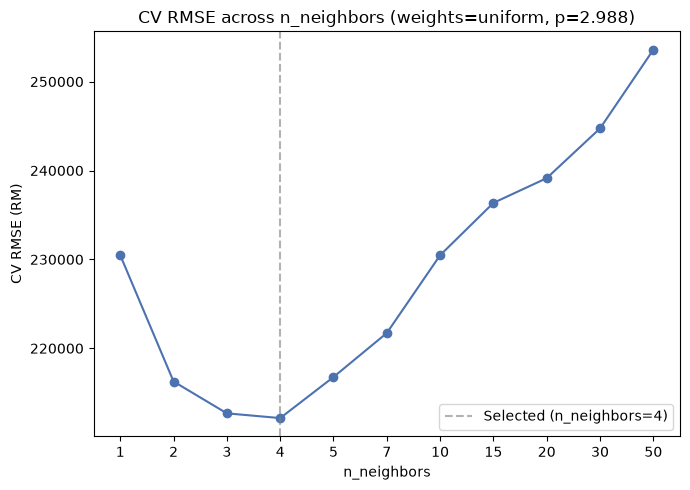

n_neighbors=1: CV RMSE=RM230,468
n_neighbors=2: CV RMSE=RM216,265
n_neighbors=3: CV RMSE=RM212,683
n_neighbors=4: CV RMSE=RM212,151
n_neighbors=5: CV RMSE=RM216,770
n_neighbors=7: CV RMSE=RM221,718
n_neighbors=10: CV RMSE=RM230,470
n_neighbors=15: CV RMSE=RM236,358
n_neighbors=20: CV RMSE=RM239,143
n_neighbors=30: CV RMSE=RM244,737
n_neighbors=50: CV RMSE=RM253,585


In [7]:
import matplotlib.pyplot as plt

best = bayes_search.best_params_
k_candidates = sorted({1, 2, 3, 5, 7, 10, 15, 20, 30, 50, best["knn__n_neighbors"]})
cv_rmse_by_k = []

for k in k_candidates:
    if k == best["knn__n_neighbors"]:
        cv_rmse_by_k.append(cv_results["mean"]["RMSE"])
        continue
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=k, weights=best["knn__weights"], p=best["knn__p"])),
    ])
    cv = cross_validate_model(pipeline, X_train, y_train, n_splits=5)
    cv_rmse_by_k.append(cv["mean"]["RMSE"])

k_labels = [str(k) for k in k_candidates]

plt.figure(figsize=(7, 5))
plt.plot(k_labels, cv_rmse_by_k, marker="o", color="#4c72b0")
plt.axvline(x=k_labels.index(str(best["knn__n_neighbors"])), color="grey", linestyle="--", alpha=0.6, label=f"Selected (n_neighbors={best['knn__n_neighbors']})")
plt.xlabel("n_neighbors")
plt.ylabel("CV RMSE (RM)")
plt.title(f"CV RMSE across n_neighbors (weights={best['knn__weights']}, p={best['knn__p']:.3f})")
plt.legend()
plt.tight_layout()
plt.show()

for k, r in zip(k_candidates, cv_rmse_by_k):
    print(f"n_neighbors={k}: CV RMSE=RM{r:,.0f}")


## Effect of p
`p` swept across `Real(1.0, 5.0)` (others fixed at final values).

5-fold CV (mean +/- std):
  RMSE:  RM 223,705 +/- 34,633  (63.6% of median price)
  MAE:   RM 101,378 +/- 6,784
  MAPE:  23.2% +/- 1.3%
  R2:    0.5309 +/- 0.0408
5-fold CV (mean +/- std):
  RMSE:  RM 222,950 +/- 28,235  (63.4% of median price)
  MAE:   RM 103,014 +/- 5,275
  MAPE:  23.8% +/- 1.4%
  R2:    0.5320 +/- 0.0169
5-fold CV (mean +/- std):
  RMSE:  RM 215,368 +/- 27,647  (61.2% of median price)
  MAE:   RM 103,207 +/- 4,598
  MAPE:  24.1% +/- 1.3%
  R2:    0.5629 +/- 0.0246
5-fold CV (mean +/- std):
  RMSE:  RM 212,112 +/- 24,725  (60.3% of median price)
  MAE:   RM 104,005 +/- 4,041
  MAPE:  24.5% +/- 1.5%
  R2:    0.5747 +/- 0.0293
5-fold CV (mean +/- std):
  RMSE:  RM 218,928 +/- 30,569  (62.2% of median price)
  MAE:   RM 107,050 +/- 4,745
  MAPE:  25.3% +/- 1.7%
  R2:    0.5481 +/- 0.0409
5-fold CV (mean +/- std):
  RMSE:  RM 222,575 +/- 32,235  (63.3% of median price)
  MAE:   RM 108,642 +/- 4,663
  MAPE:  25.7% +/- 1.4%
  R2:    0.5335 +/- 0.0460


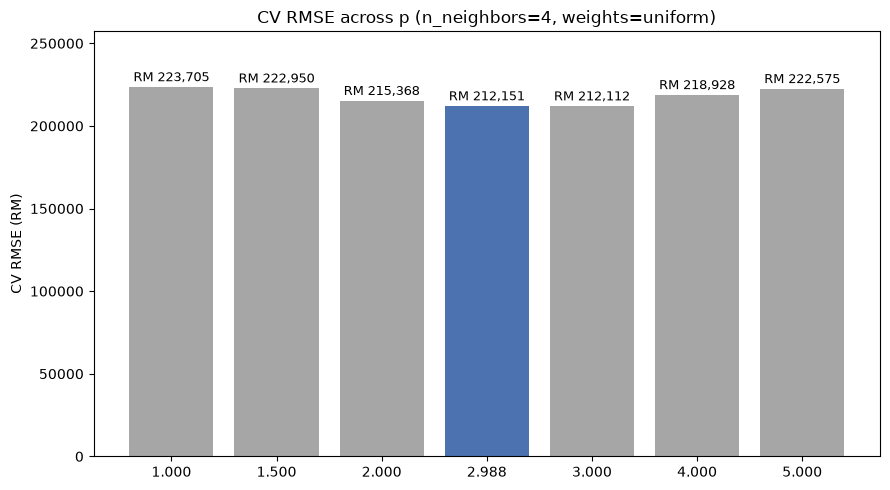

p=1.000: CV RMSE=RM223,705
p=1.500: CV RMSE=RM222,950
p=2.000: CV RMSE=RM215,368
p=2.988: CV RMSE=RM212,151
p=3.000: CV RMSE=RM212,112
p=4.000: CV RMSE=RM218,928
p=5.000: CV RMSE=RM222,575


In [8]:
best = bayes_search.best_params_
p_candidates = sorted({1.0, 1.5, 2.0, 3.0, 4.0, 5.0, best["knn__p"]})
cv_rmse_by_p = []

for p in p_candidates:
    if p == best["knn__p"]:
        cv_rmse_by_p.append(cv_results["mean"]["RMSE"])
        continue
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=best["knn__n_neighbors"], weights=best["knn__weights"], p=p)),
    ])
    cv = cross_validate_model(pipeline, X_train, y_train, n_splits=5)
    cv_rmse_by_p.append(cv["mean"]["RMSE"])

p_labels = [f"{p:.3f}" for p in p_candidates]
colors = ["#4c72b0" if p == best["knn__p"] else "#a6a6a6" for p in p_candidates]

plt.figure(figsize=(9, 5))
plt.bar(p_labels, cv_rmse_by_p, color=colors)
plt.ylabel("CV RMSE (RM)")
plt.title(f"CV RMSE across p (n_neighbors={best['knn__n_neighbors']}, weights={best['knn__weights']})")
plt.ylim(0, max(cv_rmse_by_p) * 1.15)
for i, v in enumerate(cv_rmse_by_p):
    plt.text(i, v + max(cv_rmse_by_p) * 0.015, f"RM {v:,.0f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

for p, r in zip(p_labels, cv_rmse_by_p):
    print(f"p={p}: CV RMSE=RM{r:,.0f}")


## Effect of weights

5-fold CV (mean +/- std):
  RMSE:  RM 208,304 +/- 25,373  (59.2% of median price)
  MAE:   RM 98,359 +/- 4,681
  MAPE:  23.1% +/- 1.5%
  R2:    0.5903 +/- 0.0278


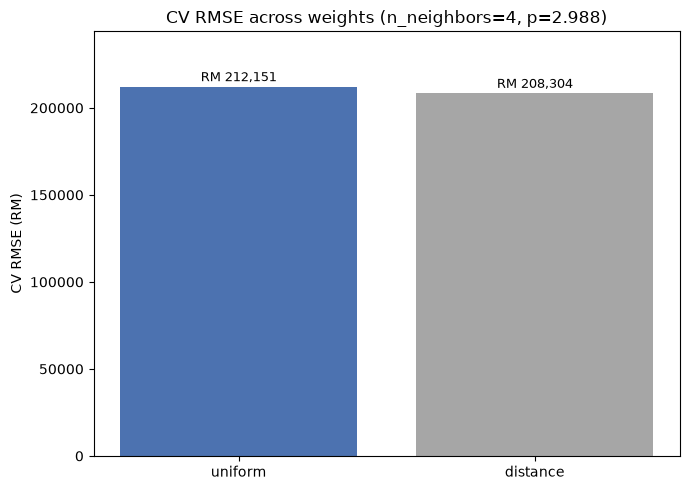

weights=uniform: CV RMSE=RM212,151
weights=distance: CV RMSE=RM208,304


In [9]:
best = bayes_search.best_params_
weight_candidates = ["uniform", "distance"]
cv_rmse_by_w = []

for w in weight_candidates:
    if w == best["knn__weights"]:
        cv_rmse_by_w.append(cv_results["mean"]["RMSE"])
        continue
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=best["knn__n_neighbors"], weights=w, p=best["knn__p"])),
    ])
    cv = cross_validate_model(pipeline, X_train, y_train, n_splits=5)
    cv_rmse_by_w.append(cv["mean"]["RMSE"])

colors = ["#4c72b0" if w == best["knn__weights"] else "#a6a6a6" for w in weight_candidates]

plt.figure(figsize=(7, 5))
plt.bar(weight_candidates, cv_rmse_by_w, color=colors)
plt.ylabel("CV RMSE (RM)")
plt.title(f"CV RMSE across weights (n_neighbors={best['knn__n_neighbors']}, p={best['knn__p']:.3f})")
plt.ylim(0, max(cv_rmse_by_w) * 1.15)
for i, v in enumerate(cv_rmse_by_w):
    plt.text(i, v + max(cv_rmse_by_w) * 0.015, f"RM {v:,.0f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

for w, r in zip(weight_candidates, cv_rmse_by_w):
    print(f"weights={w}: CV RMSE=RM{r:,.0f}")
